# Signal Research Notebook

Interactive research and development notebook for signal creation and testing.

## Workflow
1. **Load & Explore Data** - Load market data and inspect distributions
2. **Develop Signal** - Build and test signal logic interactively
3. **Implement** - Copy validated logic to `create_signal.py`
4. **Execute** - Run `uv run create-signal` to generate `data/signal.parquet`
5. **Validate Signal** - use `uv run ew-dash` to view signal characteristics.
6. **Backtest** - Use `uv run backtest` for slurm backtest on super computer
7. **Performance** - Use `uv run opt-dash` for in depth analysis of mvo backtested signal.

## Tips
- Use cells to isolate different aspects of your signal
- Modify parameters directly in cells to test variations
- Check signal statistics regularly to catch issues early
- Document your assumptions and findings as you develop

## Setup

In [1]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols

## 1. Load & Explore Data

Load your market data and inspect key characteristics before developing the signal.

In [2]:
# Configurations

# industry_cols = ['date', 'barrid', 'USSLOWL_AERODEF']

industry_cols = [
        "date", "barrid",
        "USSLOWL_AERODEF", "USSLOWL_AIRLINES", "USSLOWL_ALUMSTEL", "USSLOWL_APPAREL",
        "USSLOWL_AUTO", "USSLOWL_BANKS", "USSLOWL_BEVTOB", "USSLOWL_BIOLIFE",
        "USSLOWL_BLDGPROD", "USSLOWL_CHEM", "USSLOWL_CNSTENG", "USSLOWL_CNSTMACH",
        "USSLOWL_CNSTMATL", "USSLOWL_COMMEQP", "USSLOWL_COMPELEC", "USSLOWL_COMSVCS",
        "USSLOWL_CONGLOM", "USSLOWL_CONTAINR", "USSLOWL_DISTRIB", "USSLOWL_DIVFIN",
        "USSLOWL_ELECEQP", "USSLOWL_ELECUTIL", "USSLOWL_FOODPROD", "USSLOWL_FOODRET",
        "USSLOWL_GASUTIL", "USSLOWL_HLTHEQP", "USSLOWL_HLTHSVCS", "USSLOWL_HOMEBLDG",
        "USSLOWL_HOUSEDUR", "USSLOWL_INDMACH", "USSLOWL_INSURNCE", "USSLOWL_INTERNET",
        "USSLOWL_LEISPROD", "USSLOWL_LEISSVCS", "USSLOWL_LIFEINS", "USSLOWL_MEDIA",
        "USSLOWL_MGDHLTH", "USSLOWL_MULTUTIL", "USSLOWL_OILGSCON", "USSLOWL_OILGSDRL",
        "USSLOWL_OILGSEQP", "USSLOWL_OILGSEXP", "USSLOWL_PAPER", "USSLOWL_PHARMA",
        "USSLOWL_PRECMTLS", "USSLOWL_PSNLPROD", "USSLOWL_REALEST", "USSLOWL_RESTAUR",
        "USSLOWL_ROADRAIL", "USSLOWL_SEMICOND", "USSLOWL_SEMIEQP", "USSLOWL_SOFTWARE",
        "USSLOWL_SPLTYRET", "USSLOWL_SPTYCHEM", "USSLOWL_SPTYSTOR", "USSLOWL_TELECOM",
        "USSLOWL_TRADECO", "USSLOWL_TRANSPRT", "USSLOWL_WIRELESS",
    ]

industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

start = dt.date(2012, 1, 1)
end = dt.date(2024, 12, 31)

asset_columns = ['barrid', 'date', 'predicted_beta', 'return', 'specific_risk', 'price']

In [3]:
# Create Industry_exposure_df
# 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
industry_exposures_df = sfd.load_exposures(
    start=start, 
    end=end, 
    in_universe=True,
    columns=industry_cols
)

industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

industry_exposures_df = industry_exposures_df.with_columns(
    pl.when(pl.col(c) == pl.col(c).max())
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .cast(pl.Int8)
    .alias(c)
    for c in industry_only
)

industry_exposures_df

date,barrid,USSLOWL_AERODEF,USSLOWL_AIRLINES,USSLOWL_ALUMSTEL,USSLOWL_APPAREL,USSLOWL_AUTO,USSLOWL_BANKS,USSLOWL_BEVTOB,USSLOWL_BIOLIFE,USSLOWL_BLDGPROD,USSLOWL_CHEM,USSLOWL_CNSTENG,USSLOWL_CNSTMACH,USSLOWL_CNSTMATL,USSLOWL_COMMEQP,USSLOWL_COMPELEC,USSLOWL_COMSVCS,USSLOWL_CONGLOM,USSLOWL_CONTAINR,USSLOWL_DISTRIB,USSLOWL_DIVFIN,USSLOWL_ELECEQP,USSLOWL_ELECUTIL,USSLOWL_FOODPROD,USSLOWL_FOODRET,USSLOWL_GASUTIL,USSLOWL_HLTHEQP,USSLOWL_HLTHSVCS,USSLOWL_HOMEBLDG,USSLOWL_HOUSEDUR,USSLOWL_INDMACH,USSLOWL_INSURNCE,USSLOWL_INTERNET,USSLOWL_LEISPROD,USSLOWL_LEISSVCS,USSLOWL_LIFEINS,USSLOWL_MEDIA,USSLOWL_MGDHLTH,USSLOWL_MULTUTIL,USSLOWL_OILGSCON,USSLOWL_OILGSDRL,USSLOWL_OILGSEQP,USSLOWL_OILGSEXP,USSLOWL_PAPER,USSLOWL_PHARMA,USSLOWL_PRECMTLS,USSLOWL_PSNLPROD,USSLOWL_REALEST,USSLOWL_RESTAUR,USSLOWL_ROADRAIL,USSLOWL_SEMICOND,USSLOWL_SEMIEQP,USSLOWL_SOFTWARE,USSLOWL_SPLTYRET,USSLOWL_SPTYCHEM,USSLOWL_SPTYSTOR,USSLOWL_TELECOM,USSLOWL_TRADECO,USSLOWL_TRANSPRT,USSLOWL_WIRELESS
date,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
2013-07-31,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-01,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-02,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-05,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-06,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-12-24,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-26,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-27,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
# create the assets data frame

assets_df = sfd.load_assets(
    start=start,
    end=end,
    columns=asset_columns,
    in_universe=True,
)

assets_df

barrid,date,predicted_beta,return,specific_risk,price
str,date,f64,f64,f64,f64
"""USA06Z1""",2013-07-31,0.34349,-0.1595,55.056916,6.26
"""USA06Z1""",2013-08-01,0.353329,0.9585,55.028021,6.32
"""USA06Z1""",2013-08-02,0.363624,-0.1582,54.807402,6.31
"""USA06Z1""",2013-08-05,0.356596,2.2187,54.76671,6.45
"""USA06Z1""",2013-08-06,0.399196,-2.4806,54.692162,6.29
…,…,…,…,…,…
"""USBQOR1""",2024-12-24,1.287294,2.5872,26.800417,70.58
"""USBQOR1""",2024-12-26,1.288943,4.293,27.172284,73.61
"""USBQOR1""",2024-12-27,1.294801,-5.108,27.468053,69.85


In [5]:
# # Perform left merge on assets data frame with indsutry exposure data frame

# df = assets_df.join(
#     industry_exposures_df, on=['date', 'barrid'], how='left'
#     )

# # calculate log returns and shift them

# df = (df
#       .with_columns(
#           pl.col('return')
#           .truediv(100)
#       )
#       .with_columns(
#           pl.col('return')
#           .log1p()
#           .alias('logreturn')
#       )
#       .sort(['date', 'barrid'])
# )
# df

industry_map = (
        industry_exposures_df                          # wide: barrid, date, 59 industry cols
        .unpivot(
            on=industry_only,
            index=["barrid", "date"],                 # only carry the keys through the explosion
            variable_name="industry",
            value_name="val",
        )
        .filter(pl.col("val") == 1)                   # keep only the industry each stock belongs to
        .drop("val")                                   # no longer needed
    )

industry_map

barrid,date,industry
str,date,str
"""USA1FI1""",2012-01-03,"""USSLOWL_AERODEF"""
"""USA1FI1""",2012-01-04,"""USSLOWL_AERODEF"""
"""USA1FI1""",2012-01-05,"""USSLOWL_AERODEF"""
"""USA1FI1""",2012-01-06,"""USSLOWL_AERODEF"""
"""USA1FI1""",2012-01-09,"""USSLOWL_AERODEF"""
…,…,…
"""USBC7W1""",2019-07-24,"""USSLOWL_WIRELESS"""
"""USBC7W1""",2019-07-25,"""USSLOWL_WIRELESS"""
"""USBC7W1""",2019-07-26,"""USSLOWL_WIRELESS"""


In [6]:
# long = (
#     df
#     .unpivot(
#         on=industry_only,          # columns to melt
#         index=["barrid", "date", "return", "predicted_beta", "specific_risk", "price"],  # columns to keep as-is
#         variable_name="industry",
#         value_name="val",
#     )
#     .filter(pl.col("val") == 1)    # keep only rows where stock IS in that industry
#     .drop("val")
#     .sort(['date', 'industry'])
# )

# long

long = (
        industry_map
        .join(assets_df, on=["barrid", "date"], how="left")
        .with_columns(pl.col("return").truediv(100))
        .with_columns(pl.col("return").log1p().alias("logreturn"))
        .sort(["date", "industry"])
    )

long

barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn
str,date,str,f64,f64,f64,f64,f64
"""USABUY1""",2012-01-03,"""USSLOWL_AERODEF""",1.015225,0.011861,12.588761,74.22,0.011791
"""USABLZ1""",2012-01-03,"""USSLOWL_AERODEF""",1.193894,0.0031,19.072438,38.83,0.003095
"""USA8X21""",2012-01-03,"""USSLOWL_AERODEF""",0.94439,-0.016722,17.241816,94.08,-0.016863
"""USA9DO1""",2012-01-03,"""USSLOWL_AERODEF""",1.364087,0.015881,25.856661,21.11,0.015756
"""USAKCD1""",2012-01-03,"""USSLOWL_AERODEF""",1.288719,0.012388,19.752165,14.71,0.012312
…,…,…,…,…,…,…,…
"""USBFVL1""",2024-12-31,"""USSLOWL_TRANSPRT""",0.951489,0.008345,27.615827,43.5,0.00831
"""USA8Y11""",2024-12-31,"""USSLOWL_TRANSPRT""",1.069518,0.001495,27.834972,6.7,0.001494
"""USAPF22""",2024-12-31,"""USSLOWL_WIRELESS""",0.468975,0.003125,34.023973,16.05,0.00312


In [7]:
# Create Equal Weight Portfolio

ew_port = (
    long
    .group_by(["date", "industry"])
    .agg(
        pl.col('return').mean().alias("ew_return"),
        )
    .sort(["industry", "date"])
)

ew_port

date,industry,ew_return
date,str,f64
2012-01-03,"""USSLOWL_AERODEF""",0.005309
2012-01-04,"""USSLOWL_AERODEF""",-0.012532
2012-01-05,"""USSLOWL_AERODEF""",0.005737
2012-01-06,"""USSLOWL_AERODEF""",0.004888
2012-01-09,"""USSLOWL_AERODEF""",0.005161
…,…,…
2024-12-24,"""USSLOWL_WIRELESS""",0.013417
2024-12-26,"""USSLOWL_WIRELESS""",0.014342
2024-12-27,"""USSLOWL_WIRELESS""",0.000799


In [8]:
# Calculate Momentum

industry_momentum = (
    ew_port
    .sort(['date', 'industry'])
    .with_columns(
        pl.col('ew_return')
        .rolling_sum(window_size=230)
        .over('industry')
        .alias('momentum')
    )
    .with_columns(
        pl.col('momentum')
        .shift(22)
        .over('industry')
    )
)
industry_momentum

date,industry,ew_return,momentum
date,str,f64,f64
2012-01-03,"""USSLOWL_AERODEF""",0.005309,null
2012-01-03,"""USSLOWL_AIRLINES""",-0.015874,null
2012-01-03,"""USSLOWL_ALUMSTEL""",0.056771,null
2012-01-03,"""USSLOWL_APPAREL""",-0.006968,null
2012-01-03,"""USSLOWL_AUTO""",0.03299,null
…,…,…,…
2024-12-31,"""USSLOWL_SPTYSTOR""",0.002818,0.054439
2024-12-31,"""USSLOWL_TELECOM""",0.00323,0.177403
2024-12-31,"""USSLOWL_TRADECO""",0.002342,0.228873


In [9]:
# go back to stock space and filter price

long = (long
        .join(industry_momentum, on=['date', 'industry'], how='left')
        .filter(pl.col('price') >= 5)
        )
long

barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn,ew_return,momentum
str,date,str,f64,f64,f64,f64,f64,f64,f64
"""USABUY1""",2012-01-03,"""USSLOWL_AERODEF""",1.015225,0.011861,12.588761,74.22,0.011791,0.005309,null
"""USABLZ1""",2012-01-03,"""USSLOWL_AERODEF""",1.193894,0.0031,19.072438,38.83,0.003095,0.005309,null
"""USA8X21""",2012-01-03,"""USSLOWL_AERODEF""",0.94439,-0.016722,17.241816,94.08,-0.016863,0.005309,null
"""USA9DO1""",2012-01-03,"""USSLOWL_AERODEF""",1.364087,0.015881,25.856661,21.11,0.015756,0.005309,null
"""USAKCD1""",2012-01-03,"""USSLOWL_AERODEF""",1.288719,0.012388,19.752165,14.71,0.012312,0.005309,null
…,…,…,…,…,…,…,…,…,…
"""USBFVL1""",2024-12-31,"""USSLOWL_TRANSPRT""",0.951489,0.008345,27.615827,43.5,0.00831,0.003458,0.182653
"""USA8Y11""",2024-12-31,"""USSLOWL_TRANSPRT""",1.069518,0.001495,27.834972,6.7,0.001494,0.003458,0.182653
"""USAPF22""",2024-12-31,"""USSLOWL_WIRELESS""",0.468975,0.003125,34.023973,16.05,0.00312,0.023106,0.217237


In [10]:
# z-score momentum

industry_momentum = long.with_columns(
    ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
      pl.col("momentum").std().over("date"))
    .alias("score")
)

industry_momentum


barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn,ew_return,momentum,score
str,date,str,f64,f64,f64,f64,f64,f64,f64,f64
"""USABUY1""",2012-01-03,"""USSLOWL_AERODEF""",1.015225,0.011861,12.588761,74.22,0.011791,0.005309,null,null
"""USABLZ1""",2012-01-03,"""USSLOWL_AERODEF""",1.193894,0.0031,19.072438,38.83,0.003095,0.005309,null,null
"""USA8X21""",2012-01-03,"""USSLOWL_AERODEF""",0.94439,-0.016722,17.241816,94.08,-0.016863,0.005309,null,null
"""USA9DO1""",2012-01-03,"""USSLOWL_AERODEF""",1.364087,0.015881,25.856661,21.11,0.015756,0.005309,null,null
"""USAKCD1""",2012-01-03,"""USSLOWL_AERODEF""",1.288719,0.012388,19.752165,14.71,0.012312,0.005309,null,null
…,…,…,…,…,…,…,…,…,…,…
"""USBFVL1""",2024-12-31,"""USSLOWL_TRANSPRT""",0.951489,0.008345,27.615827,43.5,0.00831,0.003458,0.182653,-0.067727
"""USA8Y11""",2024-12-31,"""USSLOWL_TRANSPRT""",1.069518,0.001495,27.834972,6.7,0.001494,0.003458,0.182653,-0.067727
"""USAPF22""",2024-12-31,"""USSLOWL_WIRELESS""",0.468975,0.003125,34.023973,16.05,0.00312,0.023106,0.217237,0.224074


In [11]:
# compute alpha

industry_momentum = (
    industry_momentum
    .with_columns(
        pl.col('specific_risk')
        .truediv(100)
    )
    .with_columns(
        pl.col('score')
        .mul(.05)
        .mul(pl.col('specific_risk'))
        .alias('alpha')
    )
    .drop_nulls()
)

industry_momentum

barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn,ew_return,momentum,score,alpha
str,date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""USA4HN1""",2013-01-03,"""USSLOWL_AERODEF""",0.865991,0.005734,0.138223,59.64,0.005718,0.001941,0.128527,-0.097526,-0.000674
"""USA9DO1""",2013-01-03,"""USSLOWL_AERODEF""",1.550827,0.037037,0.234912,17.92,0.036368,0.001941,0.128527,-0.097526,-0.001146
"""USA4F72""",2013-01-03,"""USSLOWL_AERODEF""",1.137237,0.03132,0.369214,9.22,0.03084,0.001941,0.128527,-0.097526,-0.0018
"""USAGKQ1""",2013-01-03,"""USSLOWL_AERODEF""",1.050043,0.005267,0.232234,45.81,0.005253,0.001941,0.128527,-0.097526,-0.001132
"""USA1FI1""",2013-01-03,"""USSLOWL_AERODEF""",1.177285,0.006732,0.295572,22.43,0.006709,0.001941,0.128527,-0.097526,-0.001441
…,…,…,…,…,…,…,…,…,…,…,…
"""USBFVL1""",2024-12-31,"""USSLOWL_TRANSPRT""",0.951489,0.008345,0.276158,43.5,0.00831,0.003458,0.182653,-0.067727,-0.000935
"""USA8Y11""",2024-12-31,"""USSLOWL_TRANSPRT""",1.069518,0.001495,0.27835,6.7,0.001494,0.003458,0.182653,-0.067727,-0.000943
"""USAPF22""",2024-12-31,"""USSLOWL_WIRELESS""",0.468975,0.003125,0.34024,16.05,0.00312,0.023106,0.217237,0.224074,0.003812


In [12]:
def load_data() -> pl.DataFrame:
    industry_cols = [
        "date", "barrid",
        "USSLOWL_AERODEF", "USSLOWL_AIRLINES", "USSLOWL_ALUMSTEL", "USSLOWL_APPAREL",
        "USSLOWL_AUTO", "USSLOWL_BANKS", "USSLOWL_BEVTOB", "USSLOWL_BIOLIFE",
        "USSLOWL_BLDGPROD", "USSLOWL_CHEM", "USSLOWL_CNSTENG", "USSLOWL_CNSTMACH",
        "USSLOWL_CNSTMATL", "USSLOWL_COMMEQP", "USSLOWL_COMPELEC", "USSLOWL_COMSVCS",
        "USSLOWL_CONGLOM", "USSLOWL_CONTAINR", "USSLOWL_DISTRIB", "USSLOWL_DIVFIN",
        "USSLOWL_ELECEQP", "USSLOWL_ELECUTIL", "USSLOWL_FOODPROD", "USSLOWL_FOODRET",
        "USSLOWL_GASUTIL", "USSLOWL_HLTHEQP", "USSLOWL_HLTHSVCS", "USSLOWL_HOMEBLDG",
        "USSLOWL_HOUSEDUR", "USSLOWL_INDMACH", "USSLOWL_INSURNCE", "USSLOWL_INTERNET",
        "USSLOWL_LEISPROD", "USSLOWL_LEISSVCS", "USSLOWL_LIFEINS", "USSLOWL_MEDIA",
        "USSLOWL_MGDHLTH", "USSLOWL_MULTUTIL", "USSLOWL_OILGSCON", "USSLOWL_OILGSDRL",
        "USSLOWL_OILGSEQP", "USSLOWL_OILGSEXP", "USSLOWL_PAPER", "USSLOWL_PHARMA",
        "USSLOWL_PRECMTLS", "USSLOWL_PSNLPROD", "USSLOWL_REALEST", "USSLOWL_RESTAUR",
        "USSLOWL_ROADRAIL", "USSLOWL_SEMICOND", "USSLOWL_SEMIEQP", "USSLOWL_SOFTWARE",
        "USSLOWL_SPLTYRET", "USSLOWL_SPTYCHEM", "USSLOWL_SPTYSTOR", "USSLOWL_TELECOM",
        "USSLOWL_TRADECO", "USSLOWL_TRANSPRT", "USSLOWL_WIRELESS",
    ]
    industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

    start = dt.date(2012, 1, 1)
    end = dt.date(2024, 12, 31)

    asset_columns = ['barrid', 'date', 'predicted_beta', 'return', 'specific_risk', 'price']

    # Create Industry_exposure_df
    # 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
    
    industry_exposures_df = sfd.load_exposures(
        start=start, 
        end=end, 
        in_universe=True,
        columns=industry_cols
    )

    industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

    industry_exposures_df = industry_exposures_df.with_columns(
    pl.when(pl.col(c) == pl.col(c).max())
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .cast(pl.Int8)
    .alias(c)
    for c in industry_only
    )


    # create the assets data frame

    assets_df = sfd.load_assets(
        start=start,
        end=end,
        columns=asset_columns,
        in_universe=True,
    )

    # Perform left merge on assets data frame with indsutry exposure data frame

    industry_map = (
        industry_exposures_df                          # wide: barrid, date, 59 industry cols
        .unpivot(
            on=industry_only,
            index=["barrid", "date"],                 # only carry the keys through the explosion
            variable_name="industry",
            value_name="val",
        )
        .filter(pl.col("val") == 1)                   # keep only the industry each stock belongs to
        .drop("val")                                   # no longer needed
    )
    long = (
            industry_map
            .join(assets_df, on=["barrid", "date"], how="left")
            .with_columns(pl.col("return").truediv(100))
            .with_columns(pl.col("return").log1p().alias("logreturn"))
            .sort(["date", "industry"])
        )


    # Create Equal Weight Portfolio

    ew_port = (
        long
        .group_by(["date", "industry"])
        .agg(
            pl.col('return').mean().alias("ew_return"),
            )
        .sort(["industry", "date"])
    )

    return ew_port, long

ew_port, long = load_data()
        

## 2. Signal Development

Build and test your signal logic. Modify parameters and logic here to find optimal configurations.

In [13]:
def create_signal(df1: pl.DataFrame, df2: pl.DataFrame) -> pl.DataFrame:

    ew_port = df1
    long = df2
    
    # Calculate Momentum
    

    industry_momentum = (
    ew_port
    .sort(['date', 'industry'])
    .with_columns(
        pl.col('ew_return')
        .rolling_sum(window_size=230)
        .over('industry')
        .alias('momentum')
    )
    .with_columns(
        pl.col('momentum')
        .shift(22)
        .over('industry')
    )
    )
    # go back to stock space and filter price

    long = (long
        .join(industry_momentum, on=['date', 'industry'], how='left')
        .filter(pl.col('price') >= 5)
        )
    
    # z-score momentum

    industry_momentum = long.with_columns(
    ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
      pl.col("momentum").std().over("date"))
    .alias("score")
    )
    # compute alpha

    industry_momentum = (
    industry_momentum
    .with_columns(
        pl.col('specific_risk')
        .truediv(100)
    )
    .with_columns(
        pl.col('score')
        .mul(.05)
        .mul(pl.col('specific_risk'))
        .alias('alpha')
    )
    .drop_nulls()
    )

    return industry_momentum

    
industry_momentum = create_signal(ew_port, long)
industry_momentum
    


barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn,ew_return,momentum,score,alpha
str,date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""USA4HN1""",2013-01-03,"""USSLOWL_AERODEF""",0.865991,0.005734,0.138223,59.64,0.005718,0.001941,0.128527,-0.097526,-0.000674
"""USA9DO1""",2013-01-03,"""USSLOWL_AERODEF""",1.550827,0.037037,0.234912,17.92,0.036368,0.001941,0.128527,-0.097526,-0.001146
"""USA4F72""",2013-01-03,"""USSLOWL_AERODEF""",1.137237,0.03132,0.369214,9.22,0.03084,0.001941,0.128527,-0.097526,-0.0018
"""USAGKQ1""",2013-01-03,"""USSLOWL_AERODEF""",1.050043,0.005267,0.232234,45.81,0.005253,0.001941,0.128527,-0.097526,-0.001132
"""USA1FI1""",2013-01-03,"""USSLOWL_AERODEF""",1.177285,0.006732,0.295572,22.43,0.006709,0.001941,0.128527,-0.097526,-0.001441
…,…,…,…,…,…,…,…,…,…,…,…
"""USBFVL1""",2024-12-31,"""USSLOWL_TRANSPRT""",0.951489,0.008345,0.276158,43.5,0.00831,0.003458,0.182653,-0.067727,-0.000935
"""USA8Y11""",2024-12-31,"""USSLOWL_TRANSPRT""",1.069518,0.001495,0.27835,6.7,0.001494,0.003458,0.182653,-0.067727,-0.000943
"""USAPF22""",2024-12-31,"""USSLOWL_WIRELESS""",0.468975,0.003125,0.34024,16.05,0.00312,0.023106,0.217237,0.224074,0.003812


## 3. Signal Analysis

Examine signal statistics and distributions to understand its characteristics.

### Statistics

In [14]:
# sfr.get_signal_stats(signal)
sfr.get_signal_stats(industry_momentum, column='momentum')

mean,std,min,max,q25,q50,q75
f64,f64,f64,f64,f64,f64,f64
0.118994,0.238121,-1.825697,2.1535076,-0.013336,0.120726,0.248006


### Distribution

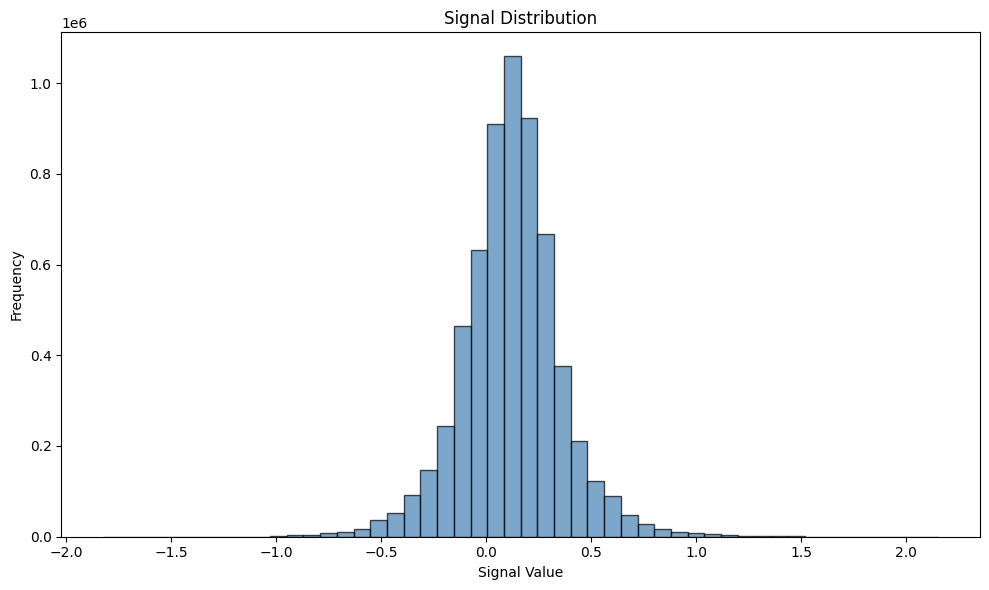

In [15]:
# sfr.get_signal_distribution(signal)
sfr.get_signal_distribution(industry_momentum, column='momentum')

## 4. Validation Checks ?

Verify signal quality and identify any issues before implementation.

## 5. Next Steps

When satisfied with your signal:

1. **Copy** your data loading and signal calculation logic to `create_signal.py`
2. **Run** `uv run create-signal` to save the signal to `data/signal.parquet`
3. **Open** `uv run ew-dash` to analyze the signal before backtesting